<a href="https://colab.research.google.com/github/sgl13/Machine_Learning/blob/main/SVM_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Support Vector Machine (SVM)**

supervised machine learning algorithm used primarily for classification and regression tasks. It works by finding an optimal decision boundary (called a hyperplane) that maximizes the margin—the distance between data points of different classes.

**Key Concepts**

**Hyperplane:** The decision boundary that separates data points of different classes. In 2D space, it is a line; in 3D, a plane; and in higher dimensions, a hyperplane.

**Support Vectors:**

The data points closest to the hyperplane. These points are critical because they define the position and orientation of the decision boundary.

**Margin:**

The distance between the hyperplane and the nearest support vectors from any class. SVM aims to maximize this margin to improve generalization.

**Kernel Trick:**

A technique used to transform non-linearly separable data into a higher-dimensional space where a linear boundary can separate the classes (common kernels include RBF, Polynomial, and Sigmoid).

**C Parameter:**

A regularization parameter that controls the trade-off between achieving a smooth decision boundary and classifying the training points correctly.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#lets create synthetic datapoints
from sklearn.datasets import make_classification

In [3]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)


In [4]:
X

array([[ 0.63339172, -0.80633849],
       [-1.00385189, -1.8321745 ],
       [-0.06580423, -1.9079845 ],
       ...,
       [-1.62815695, -2.58741878],
       [ 0.00920836,  1.86271542],
       [-0.23873178,  2.39114947]])

In [5]:
pd.DataFrame(X)[0]

,0
0,0.633392
1,-1.003852
2,-0.065804
3,0.457218
4,-0.884888
...,...
995,-1.896636
996,0.885912
997,-1.628157
998,0.009208


<Axes: xlabel='0', ylabel='1'>

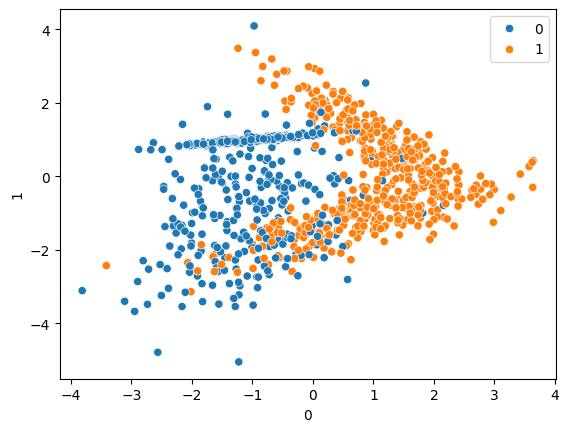

In [6]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=10)

In [8]:
from sklearn.svm import SVC

In [9]:
svc = SVC(kernel='linear')

In [10]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [11]:
#prediction
y_pred = svc.predict(X_test)

In [12]:
from sklearn.metrics import confusion_matrix,classification_report

In [13]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       146
           1       0.88      0.84      0.86       154

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

[[129  17]
 [ 25 129]]


In [14]:
rbf = SVC(kernel='rbf')

In [15]:
rbf.fit(X_train,y_train)

SVC()

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=10)

In [17]:
#prediction
y_pred1 = rbf.predict(X_test)

In [18]:
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       146
           1       0.90      0.90      0.90       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

[[131  15]
 [ 15 139]]


In [19]:
svc.coef_

array([[ 1.58855822, -0.18305937]])

In [20]:
polynomial = SVC(kernel='poly')
polynomial.fit(X_train,y_train)

SVC(kernel='poly')

In [21]:
#prediction
y_pred2 = rbf.predict(X_test)

In [22]:
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       146
           1       0.90      0.90      0.90       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

[[131  15]
 [ 15 139]]


In [23]:
sigmoid = SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)

#prediction
y_pred3 = rbf.predict(X_test)

print(classification_report(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       146
           1       0.90      0.90      0.90       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

[[131  15]
 [ 15 139]]


In [24]:
sigmoid.intercept_

array([1.23393401])

In [25]:
#hyperparametric with svc
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Defining parameter range
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid=param_grid, refit=True, cv=5, verbose=3)

# Fitting the model for grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.914 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.914 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.879 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.914 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.886 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.914 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.886 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.871 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.807 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [26]:
grid.best_params_

{'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}

In [27]:
#prediction
y_pred4 = grid.predict(X_test)

print(classification_report(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89       146
           1       0.90      0.90      0.90       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

[[130  16]
 [ 15 139]]
